<a href="https://colab.research.google.com/github/yg36/PyTorch-Learning/blob/main/02_Neural_network_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# making dataset
from sklearn.datasets import make_circles

n_samples = 1000

# create circles
X, y = make_circles(n_samples, noise = 0.03, random_state = 42)
# make_circles(): makes two circles with different colored dots
# X contains [x_position, y_position] and y contains 0 or 1(which circle it belongs to)
# noise make circles a lil messy

# print first 5
print(f"First 5 X labels are: {X[:5]}")
print(f"First 5 y labels are: {y[:5]}")

First 5 X labels are: [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 y labels are: [1 1 1 1 0]


In [ ]:
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "label": y})
circles.head(5)
# X[:,0] -> first feature i.e. x_poition
# X[:,1] -> second feature i.e. y_position

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


In [ ]:
# how many values of each class are there

circles.label.value_counts()

,count
label,
1,500
0,500


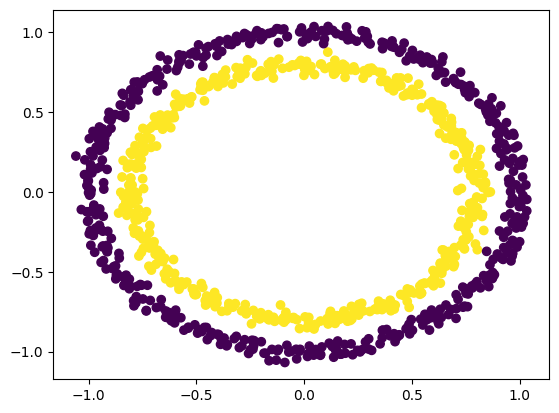

In [ ]:
# Plot them

import matplotlib.pyplot as plt

plt.scatter(x=X[:,0], y = X[:,1], c=y)

In [ ]:
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
X_sample = X[0]
y_sample = y[0]
print(f"Values of one sample: {X_sample} and y sample is {y_sample}")
print(f"Shapes of one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values of one sample: [0.75424625 0.23148074] and y sample is 1
Shapes of one sample of X: (2,) and the same for y: ()


*   means X has two features -> vector
*   and y has single dimension -> scalar

=> We have two inputs for one output

In [ ]:
import torch

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [ ]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)
    # this creates two layers:
    # layer 1 -> input:2 , output:5: two inputs are -> X1 and X2
    # layer 2 -> input:5, output:1

  def forward(self, x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# We can make the same model using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

Disadv of Sequential: As the name says it will go in sequential manner which reduces customization so we will then need to use nn.Module to define other order.

In [ ]:
# Make predictions with model
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions {len(untrained_preds)}, SHape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, SHape: {y_test.shape}")
print(f"First 10 predictions are: {untrained_preds[:10]}")
print(f"First 10 Labels are: {y_test[:10]}")

Length of predictions 200, SHape: torch.Size([200, 1])
Length of test samples: 200, SHape: torch.Size([200])
First 10 predictions are: tensor([[0.8327],
        [0.7779],
        [0.8785],
        [0.8202],
        [0.7230],
        [0.6908],
        [0.6596],
        [0.6388],
        [0.8850],
        [0.7725]], grad_fn=<SliceBackward0>)
First 10 Labels are: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [ ]:
# Loss function and optimizer
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

In [ ]:
# creating evaluation metric
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()    #torch.eq(): calculated where two tensors are equal
  acc = (correct/len(y_pred))*100

  return acc

In [ ]:
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.8327],
        [0.7779],
        [0.8785],
        [0.8202],
        [0.7230]])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

As we can see y_test and y_lofiits are not in same format. SO we need to deal with this first.

In [ ]:
# Use sigmoid function on our model logits to turn them into prediction probs
y_pred_probs= torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.6969],
        [0.6852],
        [0.7065],
        [0.6943],
        [0.6733]])

In [ ]:
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.]])

In [ ]:
# convert to predicted labels
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))
y_pred_labels
y_pred_labels.shape
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

tensor([True, True, True, True, True])


In [ ]:
# Get rid of extra dimension
y_preds.squeeze()

tensor([1., 1., 1., 1., 1.])

In [ ]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [ ]:
torch.manual_seed(42)
epochs = 100

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()

  # Forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred_probs = torch.sigmoid(y_logits)
  y_pred = torch.round(y_pred_probs)

  # Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
  # print(loss)

  optimizer.zero_grad()

  # Loss backwards
  loss.backward()

  # Update the optimizer
  optimizer.step()

  # Testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Calculate loss/accuracy
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  if epoch%10==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {acc:.2f}%")

Epoch: 0 | Loss: 0.76855, Accuracy: 50.00% | Test Loss: 0.75857, Test acc: 50.00%
Epoch: 10 | Loss: 0.71868, Accuracy: 50.00% | Test Loss: 0.71541, Test acc: 50.00%
Epoch: 20 | Loss: 0.70332, Accuracy: 50.00% | Test Loss: 0.70205, Test acc: 50.00%
Epoch: 30 | Loss: 0.69810, Accuracy: 58.63% | Test Loss: 0.69755, Test acc: 58.63%
Epoch: 40 | Loss: 0.69607, Accuracy: 52.25% | Test Loss: 0.69586, Test acc: 52.25%
Epoch: 50 | Loss: 0.69512, Accuracy: 50.75% | Test Loss: 0.69512, Test acc: 50.75%
Epoch: 60 | Loss: 0.69458, Accuracy: 50.00% | Test Loss: 0.69474, Test acc: 50.00%
Epoch: 70 | Loss: 0.69422, Accuracy: 50.12% | Test Loss: 0.69451, Test acc: 50.12%
Epoch: 80 | Loss: 0.69395, Accuracy: 49.75% | Test Loss: 0.69436, Test acc: 49.75%
Epoch: 90 | Loss: 0.69375, Accuracy: 49.62% | Test Loss: 0.69427, Test acc: 49.62%


In [ ]:
y_logits[:5]

tensor([-0.0678, -0.0831,  0.0931,  0.0831,  0.0827], grad_fn=<SliceBackward0>)

In [ ]:
y_pred_probs[:5]

tensor([0.4831, 0.4792, 0.5233, 0.5208, 0.5207], grad_fn=<SliceBackward0>)

In [ ]:
y_pred[:5]

tensor([0., 0., 1., 1., 1.], grad_fn=<SliceBackward0>)

In [ ]:
# Lets visualize whats happening

In [ ]:
import requests
from pathlib import Path

In [ ]:
# Download Helper functions from Learn Pytorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("Helper function already exists")

else:
  print("Downloading helper functions")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

  from helper_functions import plot_predictions, plot_decision_boundary

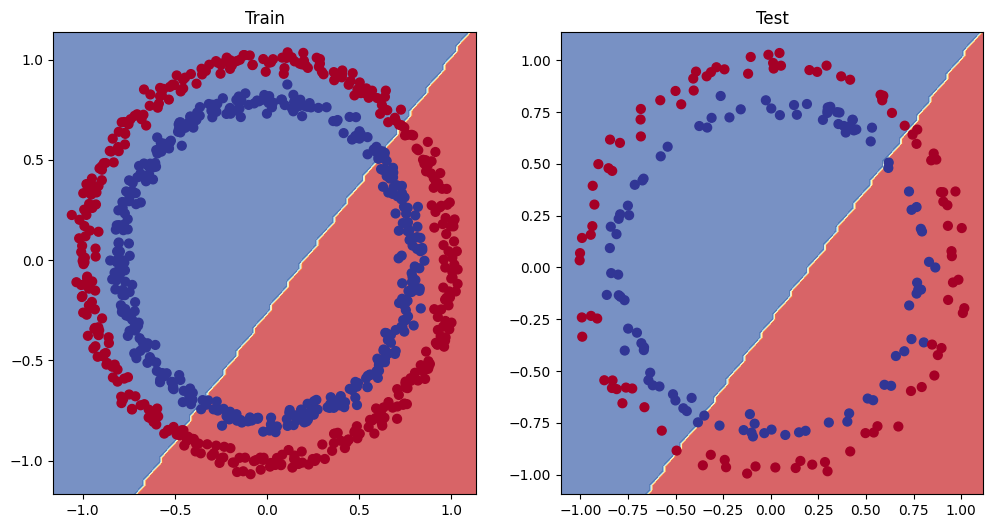

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [ ]:
# As we can see it is trying to classify using a straight line. Thats the issue!
# This is called Underfitting. Lets improve this.

In [ ]:
# Lets change a few hyper-parameters(the parameters that are set by engineer)
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss function
loss_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

In [ ]:
# training and testing loop

torch.manual_seed(42)
epochs = 1000

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  # Training
  model_1.train()
  # FOrward pass

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # Creating Loss fn
  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

  # Optimize zero gradient
  optimizer.zero_grad()

  # Backpropagate
  loss.backward()

  # Update optimizer
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
    # Forward pass
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Loss
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

  # Print whats happening
  if epoch%10==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396, Accuracy: 50.88% | Test Loss: 0.69261, Test acc: 51.00%
Epoch: 10 | Loss: 0.69369, Accuracy: 50.25% | Test Loss: 0.69270, Test acc: 50.00%
Epoch: 20 | Loss: 0.69351, Accuracy: 50.12% | Test Loss: 0.69283, Test acc: 49.50%
Epoch: 30 | Loss: 0.69339, Accuracy: 50.50% | Test Loss: 0.69297, Test acc: 48.00%
Epoch: 40 | Loss: 0.69329, Accuracy: 50.38% | Test Loss: 0.69310, Test acc: 49.00%
Epoch: 50 | Loss: 0.69322, Accuracy: 49.88% | Test Loss: 0.69324, Test acc: 50.00%
Epoch: 60 | Loss: 0.69317, Accuracy: 49.38% | Test Loss: 0.69336, Test acc: 51.50%
Epoch: 70 | Loss: 0.69312, Accuracy: 49.38% | Test Loss: 0.69348, Test acc: 50.50%
Epoch: 80 | Loss: 0.69309, Accuracy: 50.12% | Test Loss: 0.69359, Test acc: 50.00%
Epoch: 90 | Loss: 0.69307, Accuracy: 50.50% | Test Loss: 0.69370, Test acc: 48.50%
Epoch: 100 | Loss: 0.69305, Accuracy: 50.38% | Test Loss: 0.69379, Test acc: 48.00%
Epoch: 110 | Loss: 0.69303, Accuracy: 50.88% | Test Loss: 0.69388, Test acc: 46.50%
Epo

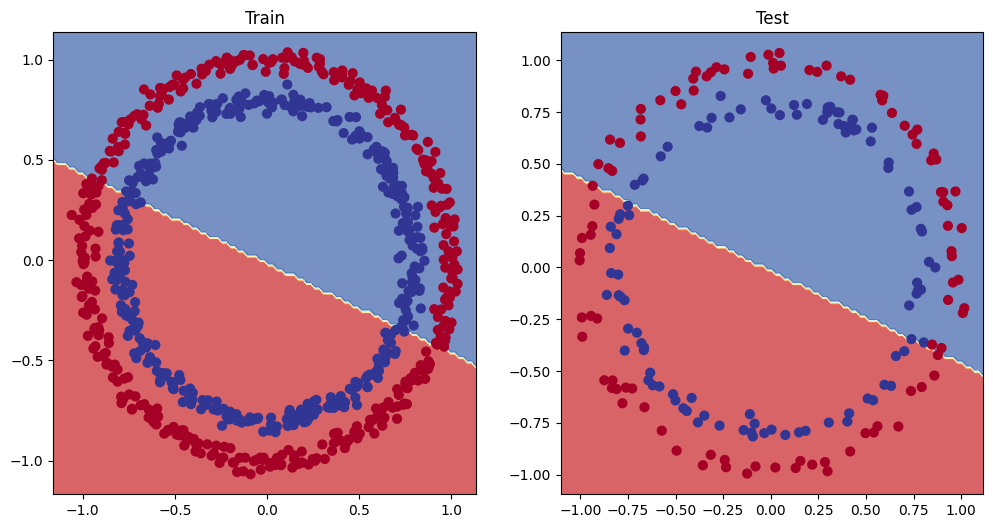

In [ ]:
# Again visualize
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)


In [ ]:
# Model is still trying to fit into straight line. Lt=ets try linear data then


In [ ]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start,end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [ ]:
# split

In [ ]:
# X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(X_regression, y_regression, test_size=0.2)

In [ ]:
train_split = int(0.8 * len(X_regression)) # 80% of data used for training set
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

In [ ]:
print(len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression))

80 80 20 20


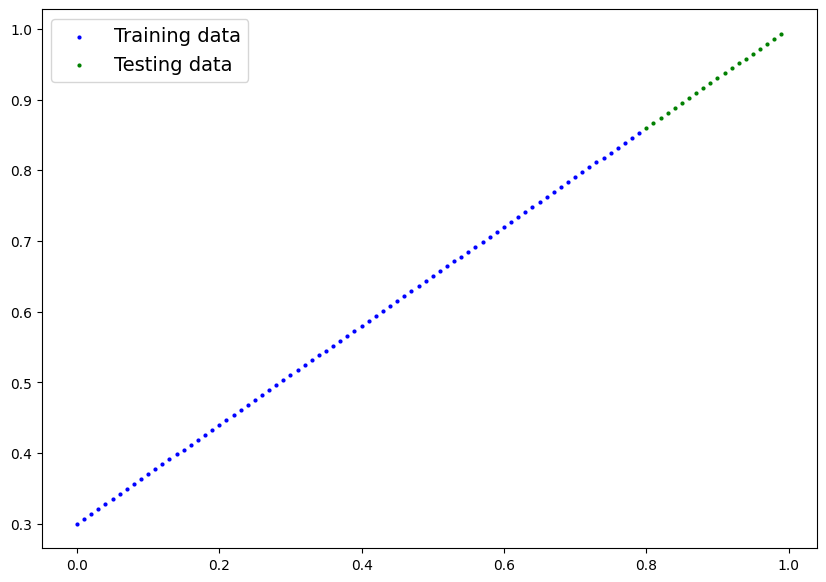

In [ ]:
plot_predictions(train_data=X_train_regression, train_labels=y_train_regression, test_data=X_test_regression, test_labels=y_test_regression)

In [ ]:
# Adjusting model_1 to fit straight line

model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
# Loss fn and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [ ]:
# Training and testing
torch.manual_seed(42)

epochs=1000

for epoch in range(epochs):
  # Training
  model_2.train()

  # Forward pass
  y_pred = model_2(X_train_regression.to(device)).squeeze()

  # Calculate loss
  loss = loss_fn(y_pred, y_train_regression)

  # Optimize zero gradient
  optimizer.zero_grad()

  # Loss backward
  loss.backward()

  # Optimizer step
  optimizer.step()


  # tetsing

  model_2.eval()
  # Forward pass
  with torch.inference_mode():
    test_pred = model_2(X_test_regression).squeeze()
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch%100==0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.5f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([80, 1])) that is different to the input size (torch.Size([80])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:129: UserWarning: Using a target size (torch.Size([20, 1])) that is different to the input size (torch.Size([20])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch: 0 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 100 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 200 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 300 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 400 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 500 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 600 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 700 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 800 | Loss: 0.14000 | Test Loss: 0.34579
Epoch: 900 | Loss: 0.14000 | Test Loss: 0.34579


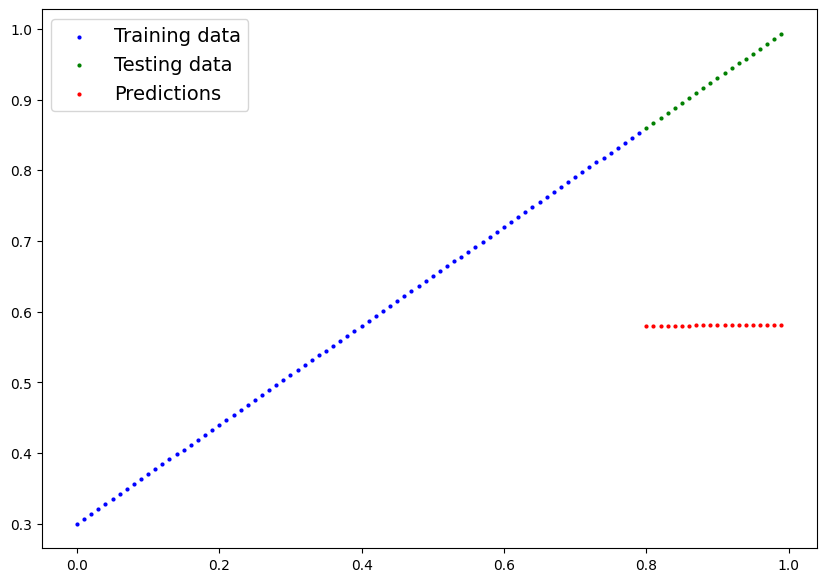

In [ ]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
    y_preds = model_2(X_test_regression)

# Plot data and predictions with data on the CPU (matplotlib can't handle data on the GPU)
# (try removing .cpu() from one of the below and see what happens)
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

In [ ]:
# Missing piece: Non-Linearity
# Lets start afresh

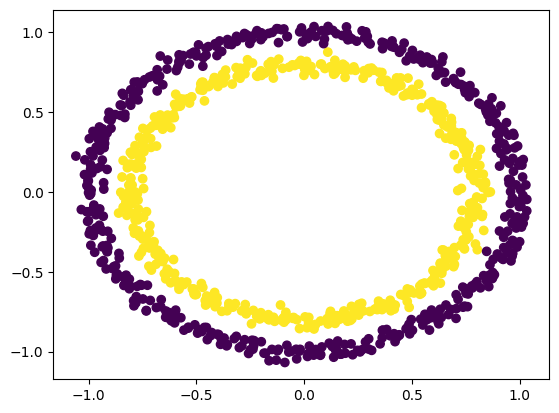

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples=1000

X,y = make_circles(n_samples=1000, noise=0.03, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y)

In [ ]:
import torch
from sklearn.model_selection import train_test_split

X_tensor = torch.from_numpy(X).type(torch.float)
y_tensor = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

X_train[:5], y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [ ]:
# Building model with non-linearity
